# Random CoPolymer Tutorial: From SMILES to MD Simulation

This notebook demonstrates a complete molecular simulation workflow using the **Multiscale Polymer Toolkit (MuPT)**. Starting from SMILES strings defining polymer repeat units, we build a random copolymer system with a `AngleConstrainedRandomWalk` to generate initial coordinates, then export it to multiple molecular modeling formats. The workflow covers the entire pipeline from chemical definition to running molecular dynamics.

The tutorial showcases MuPT's key capability: **separating molecular representation from chemistry and geometry**. We define polymer chemistry with SMILES, build hierarchical Primitive objects with embedded shapes, then export to MDAnalysis (for analysis), RDKit (for chemical manipulation), and OpenFF (for force field parameterization). Finally, we run an NPT simulation with OpenMM, demonstrating a complete path from polymer specification to production-ready MD.

NOTE: If you are testing the MD simulation via OpenMM, make sure you have access to a GPU. We want CUDA to show up and run when you run the following command: `python -m openmm.testInstallation` in the terminal. You should see something like: 

>OpenMM Version: 8.4
>Git Revision: 47684368dbbe4185d068be77d32a962059cfc37c
>
>There are 3 Platforms available:
>
>1 Reference - Successfully computed forces
>2 CPU - Successfully computed forces
>3 CUDA - Successfully computed forces
>
>Median difference in forces between platforms:
>
>Reference vs. CPU: 6.28082e-06
>Reference vs. CUDA: 6.74689e-06
>CPU vs. CUDA: 7.61024e-07
>
>All differences are within tolerance.


## 1. Setup and Imports

In [1]:
import numpy as np
from pathlib import Path

# MuPT building utilities
from mupt.builders.copolymer import (
    build_copolymer_system,
)

# MuPT export interfaces
from mupt.interfaces.rdkit.exporters import primitive_to_rdkit_hierarchical
from mupt.interfaces.mdanalysis.exporters import primitive_to_mdanalysis
from mupt.interfaces.openff import (
    primitive_to_openff_molecules,
    save_openff_system,
    load_openff_system,
)

# Visualization
from IPython.display import display

## 2. Define Polymer System

Specify the chemistry and composition of your copolymer system:
- **SMILES** for each repeat unit type (head, middle monomers, tail)
- **Monomer distribution** for the middle units
- **System parameters** (chain count, lengths, etc.)

### SMILES Conventions
- Atom map number `[*:1]` marks the **head** connection site (ANTERO direction)
- Atom map number `[*:2]` marks the **tail** connection site (RETRO direction)
- Use `*` for linker atoms that will be removed during chain connection

In [2]:
# Define repeat unit chemistry
# This example creates a PSU/PES copolymer (polysulfone/polyethersulfone)
rep_unit_smiles: dict[str, str] = {
    'head': '[H]-[O:1]c1ccc(cc1)S(=O)(=O)c1cc[c:2](cc1)-*',
    'bisphenol_S': '*-[O:1]c1ccc(cc1)S(=O)(=O)c1cc[c:2](cc1)-*',
    'bisphenol_A': '*-[O:1]c1ccc(cc1)C(-C)(-C)c1cc[c:2](cc1)-*',
    'tail': '*-[O:1]c1ccc(cc1)S(=O)(=O)c1ccc(cc1)[O:2]-[H]',
}

# Define middle monomer distribution (must sum to 1.0)
rep_unit_distrib_mid: dict[str, float] = {
    'bisphenol_S': 0.4,  # 40% PES units
    'bisphenol_A': 0.6,  # 60% PSU units
}

# System parameters
n_chains: int = 10           # Number of polymer chains
chain_len_min: int = 5       # Minimum chain length (repeat units)
chain_len_max: int = 20      # Maximum chain length

# Placement parameters
R_excl: float = 20.0         # Starting radius from origin
bond_length: float = 1.5     # Distance between repeat unit centers
angle_max_rad: float = np.pi / 4  # Maximum bend angle

print(f"System: {n_chains} chains with {chain_len_min}-{chain_len_max} monomers each")
print(f"Composition: {rep_unit_distrib_mid}")

System: 10 chains with 5-20 monomers each
Composition: {'bisphenol_S': 0.4, 'bisphenol_A': 0.6}


## 3. Build the Polymer System

The `build_copolymer_system` function:
1. Parses SMILES into oriented Primitive objects (with ellipsoidal shapes)
2. Generates random chain sequences from the monomer distribution
3. Places chains using an angle-constrained random walk (NOTE: This will eventually be replaced by the DPD initializer)
4. Returns a universe Primitive with hierarchy: `universe → chains → residues → atoms`

In [3]:
# Build the polymer system
univprim = build_copolymer_system(
    rep_unit_smiles=rep_unit_smiles,
    mid_distrib=rep_unit_distrib_mid,
    n_chains=n_chains,
    chain_len_min=chain_len_min,
    chain_len_max=chain_len_max,
    bond_length=bond_length,
    angle_max_rad=angle_max_rad,
    exclusion_radius=R_excl,
    random_seed=42,  # For reproducibility
)

# Display hierarchy summary
print(univprim.hierarchy_summary(to_depth=2))

Output()

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

...

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

Attempting to infer internal connections automatically from given topology; user should verify the connections 
assigned make sense!

universe
├── 11-mer_chain
├── 8-mer_chain
├── 17-mer_chain
├── 19-mer_chain
├── 15-mer_chain
├── 12-mer_chain
├── 17-mer_chain
├── 9-mer_chain
├── 11-mer_chain
└── 14-mer_chain


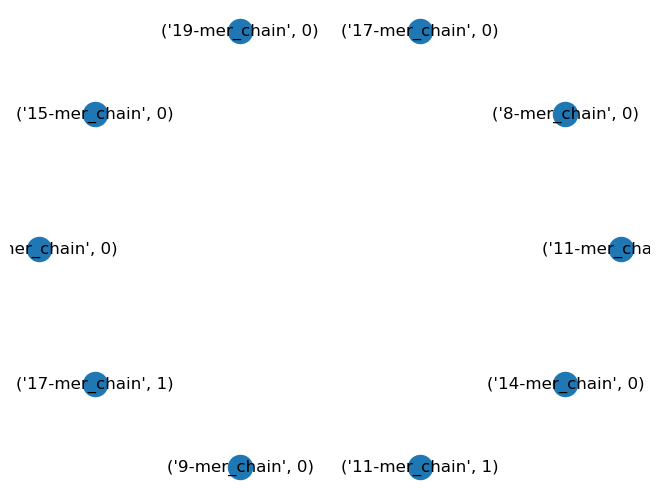

In [4]:
# Visualize the topology (optional)
univprim.visualize_topology()

## 4. Generate Residue Name Mapping

For PDB/OpenFF export, we need 3-character residue names. The helper function
creates a mapping from full monomer names to PDB-compliant abbreviations.

In [5]:
# Generate residue name mapping for export
# NOTE! These are the 3-character PDB-style residue codes
# You need to set these manually, unless we come up
# with a good way of deriving them automatically.

resname_mapper = {
    'head' : "HEA",
    'bisphenol_S' : "BPS",
    'bisphenol_A' : "BPA",
    'tail' : "TYL"
    }
print("Residue name mapping:")
for name, resname in resname_mapper.items():
    print(f"  {name:15} → {resname}")

Residue name mapping:
  head            → HEA
  bisphenol_S     → BPS
  bisphenol_A     → BPA
  tail            → TYL


---
## 5. Export to MDAnalysis

The MDAnalysis export creates a `Universe` object with proper topology
(atoms, residues, segments/chains, bonds). This is useful for trajectory
analysis and visualization.

In [6]:
import MDAnalysis as mda

# Export to MDAnalysis Universe
mda_universe = primitive_to_mdanalysis(univprim, resname_map=resname_mapper)

print(f"MDAnalysis Universe:")
print(f"  Atoms: {len(mda_universe.atoms)}")
print(f"  Residues: {len(mda_universe.residues)}")
print(f"  Segments (chains): {len(mda_universe.segments)}")
print(f"  Bonds: {len(mda_universe.bonds)}")

Processing inter-residue bonds...
Added 123 inter-residue bonds
Total bonds: 3874
Bond orders collected: 3874
Atoms: 3618, Residues: 133, Segments: 10
Unique atom_resindex: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132]
Unique atom_segindex: [0 1 2 3 4 5 6 7 8 9]
Total bonds collected: 3874
Total bond orders collected: 3874
Adding 3874 bonds to universe
Added 3874 bonds with 3874 bond orders
Bond order distribution: {1.0: 1584, 1.5: 2290}
MDAnalysis Universe:
  Atoms: 3618
  Residues: 133
  Segments (

In [7]:
# Example: Select by residue name
BPS_atoms = mda_universe.select_atoms("resname BPS")
print(f"\nAtoms in bisphenol_S residues: {len(BPS_atoms)}")

# Example: Iterate over chains
print("\nChain summary:")
for seg in mda_universe.segments:
    print(f"  Chain {seg.segid}: {len(seg.residues)} residues, {len(seg.atoms)} atoms")


Atoms in bisphenol_S residues: 1128

Chain summary:
  Chain 1: 11 residues, 297 atoms
  Chain 2: 8 residues, 213 atoms
  Chain 3: 17 residues, 477 atoms
  Chain 4: 19 residues, 513 atoms
  Chain 5: 15 residues, 405 atoms
  Chain 6: 12 residues, 327 atoms
  Chain 7: 17 residues, 471 atoms
  Chain 8: 9 residues, 255 atoms
  Chain 9: 11 residues, 303 atoms
  Chain 10: 14 residues, 357 atoms


---
## 6. Export to RDKit (Hierarchical)

The RDKit hierarchical export preserves:
- **Bond orders** from connector bondtypes
- **AtomPDBResidueInfo** for chain/residue metadata
- **3D coordinates** from the Primitive shapes

This is the basis for OpenFF conversion and can also be used for
direct PDB/SDF file export.

In [42]:
from collections import Counter

# Export to RDKit with hierarchy preservation
rdkit_mol = primitive_to_rdkit_hierarchical(univprim, resname_map=resname_mapper)

print(f"\nRDKit Molecule:")
print(f"  Atoms: {rdkit_mol.GetNumAtoms()}")
print(f"  Bonds: {rdkit_mol.GetNumBonds()}")

# Check bond type distribution
bond_types = Counter(bond.GetBondType().name for bond in rdkit_mol.GetBonds())
print(f"  Bond types: {dict(bond_types)}")

# Check for radicals (should be 0 for valid molecules)
radicals = sum(atom.GetNumRadicalElectrons() for atom in rdkit_mol.GetAtoms())
print(f"  Radical electrons: {radicals}")

Added 150522 atoms to RDKit molecule
Added 155991 intra-residue bonds
Added 5369 inter-residue bonds

RDKit Molecule:
  Atoms: 150522
  Bonds: 161360
  Bond types: {'AROMATIC': 65628, 'SINGLE': 91116, 'DOUBLE': 4616}
  Radical electrons: 0


In [ ]:
# Display RDKit molecule (2D depiction)
display(rdkit_mol)

---
## 7. Export to OpenFF

OpenFF (Open Force Field) provides modern force field parameterization.
The export creates OpenFF `Molecule` objects that preserve all hierarchy
metadata and can be parameterized with SMIRNOFF force fields.

In [8]:
from openff.toolkit import Molecule as OFFMolecule, Topology as OFFTopology

# Export to OpenFF Molecules (one per chain)
offmols = primitive_to_openff_molecules(univprim, resname_map=resname_mapper)

print(f"\nOpenFF Export: {len(offmols)} molecules")
for i, mol in enumerate(offmols):
    n_residues = len(list(mol.residues))
    print(f"  Chain {i+1}: {mol.n_atoms} atoms, {n_residues} residues")

Added 3618 atoms to RDKit molecule
Added 3751 intra-residue bonds
Added 123 inter-residue bonds

OpenFF Export: 10 molecules
  Chain 1: 297 atoms, 11 residues
  Chain 2: 213 atoms, 8 residues
  Chain 3: 477 atoms, 17 residues
  Chain 4: 513 atoms, 19 residues
  Chain 5: 405 atoms, 15 residues
  Chain 6: 327 atoms, 12 residues
  Chain 7: 471 atoms, 17 residues
  Chain 8: 255 atoms, 9 residues
  Chain 9: 303 atoms, 11 residues
  Chain 10: 357 atoms, 14 residues


In [9]:
# Verify metadata preservation
test_mol = offmols[0]
test_atom = list(test_mol.atoms)[0]

print("\nMetadata on first atom of first chain:")
print(f"  residue_name: {test_atom.metadata.get('residue_name', 'N/A')}")
print(f"  residue_number: {test_atom.metadata.get('residue_number', 'N/A')}")
print(f"  chain_id: {test_atom.metadata.get('chain_id', 'N/A')}")


Metadata on first atom of first chain:
  residue_name: HEA
  residue_number: 1
  chain_id: A


### 7.1 Save and Reload OpenFF System

The serialization utilities allow saving and loading the complete system
with all metadata preserved.

In [10]:
# Save the system
output_dir = Path('mupt-built_systems')
output_dir.mkdir(exist_ok=True)

system_name = f'copolymer_{n_chains}x[{chain_len_min}-{chain_len_max}]mer'
saved_files = save_openff_system(offmols, output_dir / system_name)

print(f"\nSaved files:")
for fmt, path in saved_files.items():
    print(f"  {fmt}: {path}")


Saved files:
  json: mupt-built_systems/copolymer_10x[5-20]mer.json
  sdf: mupt-built_systems/copolymer_10x[5-20]mer.sdf


In [11]:
# Reload and verify
loaded_mols = load_openff_system(saved_files['json'])

print(f"\nReloaded {len(loaded_mols)} molecules")
for i, mol in enumerate(loaded_mols):
    n_residues = len(list(mol.residues))
    print(f"  Chain {i+1}: {mol.n_atoms} atoms, {n_residues} residues")


Reloaded 10 molecules
  Chain 1: 297 atoms, 11 residues
  Chain 2: 213 atoms, 8 residues
  Chain 3: 477 atoms, 17 residues
  Chain 4: 513 atoms, 19 residues
  Chain 5: 405 atoms, 15 residues
  Chain 6: 327 atoms, 12 residues
  Chain 7: 471 atoms, 17 residues
  Chain 8: 255 atoms, 9 residues
  Chain 9: 303 atoms, 11 residues
  Chain 10: 357 atoms, 14 residues


---
## Summary

This notebook demonstrated the complete MuPT workflow:

1. **Build**: Defined polymer chemistry with SMILES and built a random copolymer system
2. **Export**: 
   - **MDAnalysis**: For trajectory analysis and visualization
   - **RDKit**: For chemical manipulation and 2D/3D structure handling
   - **OpenFF**: For force field parameterization
3. **Simulate**: Ran energy minimization and short MD with OpenMM

### Key Functions

| Function | Purpose |
|----------|--------|
| `build_copolymer_system()` | Build polymer system from SMILES |
| `primitive_to_mdanalysis()` | Export to MDAnalysis Universe |
| `primitive_to_rdkit_hierarchical()` | Export to RDKit with hierarchy |
| `primitive_to_openff_molecules()` | Export to OpenFF Molecules |
| `save_openff_system()` / `load_openff_system()` | Serialize/deserialize systems |

## 8. OpenMM Simulation (NPT Ensemble)

Now we'll run a molecular dynamics simulation using OpenMM. This section follows the optimized workflow from `mdfiles_with_openff.ipynb`:

**Key optimizations:**
1. **Per-molecule parameterization**: Parameterize each molecule individually, then combine with `Interchange.combine()`. This is significantly faster than parameterizing the whole topology at once.
2. **Automatic Partial Charge Assignment**:  We use `openff-gnn-am1bcc-1.0.0.pt`
3. **NPT ensemble**: Langevin integrator with Monte Carlo barostat for constant temperature and pressure
4. **System serialization**: Save topology, system, state, and integrator to files for reproducibility
5. **Reporters**: DCD trajectory and state data reporters for analysis

In [12]:
offdir : Path = Path('OpenFF_MD_input_files')
offdir.mkdir(exist_ok=True)
system_name : str = 'amorphous_melt'

In [13]:
# Parameterize each molecule individually, then combine (much faster than parameterizing topology)
from functools import reduce
from rich.progress import track
from openff.toolkit import ForceField
from openff.interchange import Interchange
from openff.units import unit as off_unit

ff = ForceField('openff-2.2.1.offxml')

# Assign partial charges and parameterize each molecule
mol_interchanges = []
for offmol in track(offmols, description='Parameterizing molecules'):
    # Use gasteiger for speed (use 'openff-gnn-am1bcc-1.0.0.pt' for production)
    offmol.assign_partial_charges(partial_charge_method='openff-gnn-am1bcc-1.0.0.pt') #  partial_charge_method='gasteiger'
    mol_inc = ff.create_interchange(
        offmol.to_topology(), 
        charge_from_molecules=[offmol]
    )
    mol_interchanges.append(mol_inc)

# Combine all molecule interchanges into one
# NOTE: I tested this with 100 5-10-mers ~150k atoms total and it took more
# than 20 minutes to do this last step before crashing. This may have been fixed in the
# latest version of OpenFF
interchange = reduce(Interchange.combine, mol_interchanges)
print(f"Combined interchange with {interchange.topology.n_atoms} atoms")

Output()

/home/joelaforet/miniconda3/envs/mupt-env/lib/python3.13/site-packages/openff/interchange/operations/_combine.py:104: InterchangeCombinationWarning: Interchange object combination is complex and may produce strange results outside of use cases it has been tested in. Use with caution and thoroughly validate results!
  warnings.warn(


Combined interchange with 3618 atoms


In [14]:
# Set up simulation box with padding
positions = interchange.positions
bbox_dims = np.ptp(positions, axis=0)  # Bounding box dimensions

# Add padding around the system
padding = 1.0 * off_unit.nanometer
box_lengths = (bbox_dims + 2 * padding).m_as(off_unit.nanometer)
interchange.box = np.diag(box_lengths) * off_unit.nanometer

print(f"Box dimensions: {box_lengths[0]:.2f} x {box_lengths[1]:.2f} x {box_lengths[2]:.2f} nm")

Box dimensions: 24.79 x 17.92 x 21.48 nm


In [22]:
# Simulation parameters
from openmm.unit import Quantity, kelvin, picosecond, femtosecond, nanosecond, atmosphere

# Simulation parameters
temperature : Quantity = 300.0 * kelvin
pressure : Quantity = 1.0 * atmosphere


sim_time_total : Quantity = 0.5*nanosecond
time_step : Quantity = 2.0*femtosecond
n_samples : int = 100

friction : Quantity = 1.0 / picosecond


In [23]:
# Integrator and Barostat Parameters

from openmm import LangevinMiddleIntegrator, MonteCarloBarostat

n_steps : int = round(sim_time_total / time_step)

# Create integrator and barostat
integrator = LangevinMiddleIntegrator(temperature, friction, time_step)
barostat = MonteCarloBarostat(pressure, temperature, 25)  # Update every 25 steps

# Create OpenMM simulation with barostat
simulation = interchange.to_openmm_simulation(
    integrator=integrator,
    combine_nonbonded_forces=False,  # Required for proper PME handling
    additional_forces=[barostat],
)

print(f"Created NPT simulation at {temperature} and {pressure}")

Created NPT simulation at 300.0 K and 1.0 atm


In [17]:
ag = mda_universe.select_atoms('all')
ag.write("test_copolymer_structure.pdb")

/home/joelaforet/miniconda3/envs/mupt-env/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/home/joelaforet/miniconda3/envs/mupt-env/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
/home/joelaforet/miniconda3/envs/mupt-env/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
/home/joelaforet/miniconda3/envs/mupt-env/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn(
/home/joelaforet/miniconda3/envs/mupt-env/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default va

In [24]:
# Minimize energy
print("Running energy minimization...")
simulation.minimizeEnergy()

# Get minimized state
state = simulation.context.getState(getEnergy=True, getPositions=True)
print(f"Minimized potential energy: {state.getPotentialEnergy()}")

Running energy minimization...
Minimized potential energy: -1619.606572029792 kJ/mol


In [25]:
from openmm import XmlSerializer
from openmm.app import PDBFile


ommdir = offdir / 'OpenMM'
ommdir.mkdir(exist_ok=True)

# topology
top_path : Path = ommdir / f'{system_name}_topology.pdb'
with top_path.open('w') as top_file:
    PDBFile.writeFile(simulation.topology, state.getPositions(asNumpy=True), top_file)
    
# system
sys_path : Path = ommdir / f'{system_name}_system.xml'
with sys_path.open('w') as sys_file:
    sys_file.write(XmlSerializer.serialize(simulation.system))
    
# state
state_path : Path = ommdir / f'{system_name}_state.xml'
with state_path.open('w') as state_file:
    state_file.write(XmlSerializer.serialize(state))
    
# integrator
integ_path : Path = ommdir / f'{system_name}_integrator.xml'
with integ_path.open('w') as int_file:
    int_file.write(XmlSerializer.serialize(integrator))

In [26]:
# Set up reporters for trajectory and thermodynamic data
from openmm.app import DCDReporter, StateDataReporter
import sys

# Trajectory output
report_interval : int = round(n_steps / n_samples)

dcd_path = ommdir / f'{system_name}_trajectory.dcd'
simulation.reporters.append(DCDReporter(str(dcd_path), report_interval))

state_data_path : Path = ommdir / f'{system_name}_state_data.csv'
state_params : dict[str, bool] = {
    'step' : False,
    'time' : True,
    'potentialEnergy' : True,
    'kineticEnergy' : True,
    'totalEnergy' : False,
    'temperature' : True,
    'volume' : True,
    'density' : True,
    'progress' : False,
    'remainingTime' : False,
    'speed' : True,
    'elapsedTime' : False,
}
statedata_reporter = StateDataReporter(
    str(state_data_path),
    reportInterval=report_interval,
    **state_params
)
simulation.reporters.append(statedata_reporter)

print(f"Running {n_steps} steps of NPT dynamics...")
simulation.step(n_steps)
print(f"\nTrajectory saved to: {dcd_path}")

Running 250000 steps of NPT dynamics...

Trajectory saved to: OpenFF_MD_input_files/OpenMM/amorphous_melt_trajectory.dcd


In [28]:
# Verify saved files can be reloaded
from openmm.app import PDBFile
from openmm import XmlSerializer

# Reload system
with open(sys_path, 'r') as f:
    reloaded_system = XmlSerializer.deserialize(f.read())

# Reload state
with open(state_path, 'r') as f:
    reloaded_state = XmlSerializer.deserialize(f.read())

print("Successfully reloaded serialized OpenMM components!")
print(f"  System: {reloaded_system.getNumParticles()} particles")
print(f"  State energy: {reloaded_state.getPotentialEnergy()}")
print(f"\nAll MD files saved to: {ommdir}")

Successfully reloaded serialized OpenMM components!
  System: 3618 particles
  State energy: -1619.606572029792 kJ/mol

All MD files saved to: OpenFF_MD_input_files/OpenMM
